# Runtime comparison notebook

This notebook is derived from the earlier experiment notebook and keeps only the code needed for **runtime comparison**.

It benchmarks:

1. **Regression-path algorithms** on the three regression settings used in the paper:
   - Chinese housing-price data
   - Example 2
   - Example 3
2. **$k$-means runtime** on the UCI clustering datasets:
   - original representation
   - sparsified representation
3. **Exploratory $k$-means runtime** on the Chinese housing dataset:
   - original representation
   - sparsified representation

All outputs are written to the `outputs/` directory.


In [3]:
# Setup ----------------------------------------------------------------------

dir.create("data", showWarnings = FALSE)
dir.create("outputs_runtime", showWarnings = FALSE)

install_if_missing <- function(pkgs) {
  to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
  if (length(to_install) > 0) {
    install.packages(to_install, repos = "https://cloud.r-project.org")
  }
}

install_if_missing(c("lars", "glmnet", "readxl", "cluster", "mclust", "clue", "ggplot2", "scales"))

library(lars)
library(glmnet)
library(readxl)
library(cluster)
library(mclust)
library(clue)
library(ggplot2)
library(scales)

output_dir <- "outputs_runtime"

standardize_for_path <- function(v) {
  v <- v - mean(v)
  k <- length(v) / sqrt(drop(crossprod(v)))
  v * k
}

save_plot_files <- function(plot_obj, stem, width = 8, height = 5.5, dpi = 320, bg = "white") {
  ggsave(
    filename = file.path(output_dir, paste0(stem, ".pdf")),
    plot = plot_obj,
    width = width,
    height = height,
    units = "in",
    device = cairo_pdf,
    bg = bg
  )
  ggsave(
    filename = file.path(output_dir, paste0(stem, ".png")),
    plot = plot_obj,
    width = width,
    height = height,
    units = "in",
    dpi = dpi,
    bg = bg
  )
}

benchmark_fun <- function(fun, reps = 30, warmup = 3, inner_rep = 1) {
  for (i in seq_len(warmup)) invisible(fun())

  times <- numeric(reps)
  for (i in seq_len(reps)) {
    gc(FALSE)
    times[i] <- system.time({
      for (j in seq_len(inner_rep)) invisible(fun())
    })[["elapsed"]] / inner_rep
  }

  data.frame(
    mean_sec = mean(times),
    median_sec = median(times),
    sd_sec = stats::sd(times),
    min_sec = min(times),
    max_sec = max(times),
    reps = reps,
    inner_rep = inner_rep
  )
}

sanitize_names <- function(x) {
  x <- tolower(trimws(x))
  x <- gsub("[^a-z0-9]+", "_", x)
  x <- gsub("^_+|_+$", "", x)
  x
}

find_data_file <- function(stem, search_dirs = c("data", "."), exts = c("csv", "xlsx", "xls")) {
  for (d in search_dirs) {
    if (!dir.exists(d) && d != ".") next

    for (ext in exts) {
      candidate <- file.path(d, paste0(stem, ".", ext))
      if (file.exists(candidate)) return(candidate)
    }

    pattern <- paste0("^", stem, "\\.(", paste(exts, collapse = "|"), ")$")
    matches <- list.files(d, pattern = pattern, ignore.case = TRUE, full.names = TRUE)
    if (length(matches) > 0) return(matches[1])
  }
  NA_character_
}

find_data_file_multi <- function(stems, search_dirs = c("data", "."), exts = c("csv", "xlsx", "xls")) {
  for (stem in stems) {
    f <- find_data_file(stem, search_dirs = search_dirs, exts = exts)
    if (!is.na(f)) return(f)
  }
  NA_character_
}

read_tabular_file <- function(path) {
  if (is.na(path)) stop("File not found.")
  ext <- tolower(tools::file_ext(path))
  if (ext %in% c("xlsx", "xls")) {
    as.data.frame(readxl::read_excel(path))
  } else {
    read.csv(path, check.names = FALSE, stringsAsFactors = FALSE)
  }
}

most_frequent_value <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA)
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}

impute_missing_values <- function(df) {
  for (j in seq_along(df)) {
    if (is.numeric(df[[j]])) {
      med <- stats::median(df[[j]], na.rm = TRUE)
      if (is.na(med)) med <- 0
      df[[j]][is.na(df[[j]])] <- med
    } else {
      mode_val <- most_frequent_value(df[[j]])
      df[[j]][is.na(df[[j]])] <- mode_val
      df[[j]] <- as.factor(df[[j]])
    }
  }
  df
}

SPARSE_ORTHO_BINS <- 4

sparse_orthogonalize_matrix <- function(X_scaled, n_blocks = SPARSE_ORTHO_BINS, rescale_output = TRUE) {
  X_scaled <- as.matrix(X_scaled)
  out_list <- list()
  out_names <- character(0)

  for (j in seq_len(ncol(X_scaled))) {
    x <- X_scaled[, j]
    probs <- seq(0, 1, length.out = n_blocks + 1)
    brks <- unique(as.numeric(stats::quantile(x, probs = probs, na.rm = TRUE, type = 8)))
    if (length(brks) < 2) next

    bin_id <- cut(x, breaks = brks, include.lowest = TRUE, labels = FALSE)
    if (all(is.na(bin_id))) next

    nb <- max(bin_id, na.rm = TRUE)
    for (b in seq_len(nb)) {
      comp <- numeric(length(x))
      idx <- which(bin_id == b)
      if (length(idx) == 0) next
      comp[idx] <- x[idx]
      out_list[[length(out_list) + 1]] <- comp
      out_names <- c(out_names, paste0(colnames(X_scaled)[j], "_b", b))
    }
  }

  if (length(out_list) == 0) stop("Sparse orthogonalization produced no components.")

  X_out <- do.call(cbind, out_list)
  colnames(X_out) <- out_names

  if (rescale_output) {
    for (j in seq_len(ncol(X_out))) {
      s <- stats::sd(X_out[, j])
      if (is.finite(s) && s > 0) {
        X_out[, j] <- (X_out[, j] - mean(X_out[, j])) / s
      }
    }
  }

  X_out
}

prepare_dataset_for_clustering <- function(df, dataset_key, label_candidates = c("class", "label"), drop_candidates = character(0), prefer_last_column = TRUE) {
  names(df) <- sanitize_names(names(df))
  df <- impute_missing_values(df)

  label_candidates <- sanitize_names(label_candidates)
  drop_candidates <- sanitize_names(drop_candidates)

  label_col <- intersect(label_candidates, names(df))
  if (length(label_col) == 0 && prefer_last_column) {
    label_col <- names(df)[ncol(df)]
  } else {
    label_col <- label_col[1]
  }

  y <- as.factor(df[[label_col]])
  X_df <- df[, setdiff(names(df), c(label_col, drop_candidates)), drop = FALSE]

  X_df <- data.frame(lapply(X_df, function(col) {
    if (is.factor(col) || is.character(col)) as.numeric(as.factor(col)) else as.numeric(col)
  }))

  keep <- sapply(X_df, function(z) stats::sd(z, na.rm = TRUE) > 0)
  X_df <- X_df[, keep, drop = FALSE]

  X_original <- scale(as.matrix(X_df))
  X_sparsified <- sparse_orthogonalize_matrix(X_original, n_blocks = SPARSE_ORTHO_BINS)

  list(
    X_original = X_original,
    X_sparsified = X_sparsified,
    y = y,
    n = nrow(X_original),
    p = ncol(X_original),
    p_sparse = ncol(X_sparsified),
    true_k = length(unique(y))
  )
}



Loaded lars 1.3


Warning message:
"package 'glmnet' was built under R version 4.4.3"
Loading required package: Matrix

Loaded glmnet 4.1-10

Warning message:
"package 'readxl' was built under R version 4.4.3"
Warning message:
"package 'mclust' was built under R version 4.4.3"
Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.

Warning message:
"package 'clue' was built under R version 4.4.3"


## 1. Prepare the three regression settings

This section recreates the three regression settings used in the original notebook:
- Chinese housing-price data
- Example 2
- Example 3


In [4]:
# Chinese housing-price data ---------------------------------------------------

year <- 1997:2023

y <- c(1997,2063,2053,2112,2170,2250,2359,2714,3168,3367,3864,3800,4681,5045,5384,5839,6328,6427,6932,7699,8160,9045,9673,10248,10546,10210,10438) / 1997
y <- y - mean(y)

x1 <- standardize_for_path(c(79715.0,85195.5,90564.4,100280.1,110863.1,121717.4,137422.0,161840.2,187318.9,219438.5,270092.3,319244.6,348517.7,412119.3,487940.2,538580.0,592963.2,643563.1,688858.2,746395.1,832035.9,919281.1,986515.2,1013567.0,1149237.0,1204724.0,1260582.1) / 79715.0)
x2 <- standardize_for_path(c(8651.14,9875.95,11444.08,13395.23,16386.04,18903.64,21715.25,26396.47,31649.29,38760.20,51321.78,61330.35,68518.30,83101.51,103874.43,117253.52,129209.64,140370.03,152269.23,159269.97,172592.77,183359.84,190390.08,182913.88,202554.64,203649.29,216795.43) / 8651.14)
x3 <- standardize_for_path(c(90995.3,104498.5,119897.9,134610.3,158301.9,185007.0,221222.8,254107.0,298755.7,345577.9,403442.2,475166.6,610224.5,725851.8,851590.9,974148.8,1106525.0,1228374.8,1392278.1,1550066.7,1690235.3,1826744.2,1986488.8,2186795.9,2382899.6,2664320.8,2922713.3) / 90995.3)

x4_raw <- c(100,99.2,98.6,100.4,100.7,99.2,101.2,103.9,101.8,101.5,104.8,105.9,99.3,103.3,105.4,102.6,102.6,102.0,101.4,102.0,101.6,102.1,102.9,102.5,100.9,102.0,100.2) / 100
for (i in 2:27) x4_raw[i] <- x4_raw[i - 1] * x4_raw[i]
x4 <- standardize_for_path(x4_raw)

x5 <- standardize_for_path(c(24941,28406,29855,32918,37214,43500,53841,66235,80994,97583,118323,144587,181760,218834,205036,241746,282486,320331,347827,372021,394926,418215,439541,451155,473003,495966,509708) / 24941)
x6 <- standardize_for_path(c(1175,1218,1152,1139,1128,1184,1273,1402,1451,1564,1657,1795,2021,2228,2373,2498,2643,2816,3054,3039,3105,3210,3549,3781,3891,4093,4150) / 1175)
x7 <- standardize_for_path(c(5160.3,5425.1,5854.0,6280.0,6859.6,7702.8,8472.2,9421.6,10493.0,11759.5,13785.8,15780.8,17174.7,19109.4,21809.8,24564.7,26955.1,28843.9,31194.8,33616.2,36396.2,39250.8,42358.8,43833.8,47412,49283,51821) / 5160.3)

X_housing <- cbind(x1, x2, x3, x4, x5, x6, x7)
y_housing <- y

# Example 2 -------------------------------------------------------------------

x1_f46 <- standardize_for_path(c(10,20,30,0,0,0,0,0,0,0,0,0,0,0,0,0))
x2_f46 <- standardize_for_path(c(0,0,0,40,50,60,70,80,9,10,0,0,0,0,0,0))
x3_f46 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,0,11,12,13,0,0,0))
x4_f46 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,0,0,0,0,14,15,16))

X_ex2 <- cbind(x1_f46, x2_f46, x3_f46, x4_f46)
y_ex2 <- c(-1,10,-5,-10,1,8,3,4,2,1,9,7,5,3,2,-1)
y_ex2 <- y_ex2 - mean(y_ex2)

# Example 3 -------------------------------------------------------------------

x1_f79  <- standardize_for_path(c(10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0))
x2_f79  <- standardize_for_path(c(0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0))
x3_f79  <- standardize_for_path(c(0,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0))
x4_f79  <- standardize_for_path(c(0,0,0,40,0,0,0,0,0,0,0,0,0,0,0,0))
x5_f79  <- standardize_for_path(c(0,0,0,0,50,0,0,0,0,0,0,0,0,0,0,0))
x6_f79  <- standardize_for_path(c(0,0,0,0,0,60,0,0,0,0,0,0,0,0,0,0))
x7_f79  <- standardize_for_path(c(0,0,0,0,0,0,70,0,0,0,0,0,0,0,0,0))
x8_f79  <- standardize_for_path(c(0,0,0,0,0,0,0,80,0,0,0,0,0,0,0,0))
x9_f79  <- standardize_for_path(c(0,0,0,0,0,0,0,0,9,0,0,0,0,0,0,0))
x10_f79 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,10,0,0,0,0,0,0))
x11_f79 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0))
x12_f79 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,0))
x13_f79 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,0,0,0,13,0,0,0))
x14_f79 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,0,0,0,0,14,0,0))
x15_f79 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,0))
x16_f79 <- standardize_for_path(c(0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16))

X_ex3 <- cbind(
  x1_f79, x2_f79, x3_f79, x4_f79, x5_f79, x6_f79, x7_f79, x8_f79,
  x9_f79, x10_f79, x11_f79, x12_f79, x13_f79, x14_f79, x15_f79, x16_f79
)

y_ex3 <- c(-1,10,-5,-10,1,8,3,4,2,1,9,7,5,3,2,-1)
y_ex3 <- y_ex3 - mean(y_ex3)

regression_datasets <- list(
  housing_1997_2023 = list(X = X_housing, y = y_housing, reps = 80, inner_rep = 5),
  example_2 = list(X = X_ex2, y = y_ex2, reps = 120, inner_rep = 10),
  example_3 = list(X = X_ex3, y = y_ex3, reps = 120, inner_rep = 10)
)


## 2. Benchmark regression-path algorithms

The three compared algorithms are:
- original Lasso path via `lars(..., type = "lasso")`
- Lars via `lars(..., type = "lar")`
- Glmnet via `glmnet(..., alpha = 1)`


In [5]:
# Benchmark regression-path algorithms ----------------------------------------

runtime_regression <- data.frame()

for (nm in names(regression_datasets)) {
  obj <- regression_datasets[[nm]]
  X <- obj$X
  y <- obj$y
  reps <- obj$reps
  inner_rep <- obj$inner_rep

  algs <- list(
    lasso_original = function() lars(X, y, type = "lasso"),
    lars_fast = function() lars(X, y, type = "lar"),
    glmnet_fast = function() glmnet(X, y, alpha = 1, family = "gaussian")
  )

  for (alg_name in names(algs)) {
    cat(sprintf("Benchmarking regression runtime | dataset=%s | algorithm=%s\n", nm, alg_name))
    res <- benchmark_fun(algs[[alg_name]], reps = reps, warmup = 3, inner_rep = inner_rep)
    res$dataset <- nm
    res$algorithm <- alg_name
    res$n <- nrow(X)
    res$p <- ncol(X)
    runtime_regression <- rbind(runtime_regression, res)
  }
}

runtime_regression <- runtime_regression[, c("dataset", "algorithm", "n", "p", "mean_sec", "median_sec", "sd_sec", "min_sec", "max_sec", "reps", "inner_rep")]
runtime_regression
write.csv(runtime_regression, file.path(output_dir, "runtime_regression_algorithms.csv"), row.names = FALSE)


Benchmarking regression runtime | dataset=housing_1997_2023 | algorithm=lasso_original
Benchmarking regression runtime | dataset=housing_1997_2023 | algorithm=lars_fast
Benchmarking regression runtime | dataset=housing_1997_2023 | algorithm=glmnet_fast
Benchmarking regression runtime | dataset=example_2 | algorithm=lasso_original
Benchmarking regression runtime | dataset=example_2 | algorithm=lars_fast
Benchmarking regression runtime | dataset=example_2 | algorithm=glmnet_fast
Benchmarking regression runtime | dataset=example_3 | algorithm=lasso_original
Benchmarking regression runtime | dataset=example_3 | algorithm=lars_fast
Benchmarking regression runtime | dataset=example_3 | algorithm=glmnet_fast


dataset,algorithm,n,p,mean_sec,median_sec,sd_sec,min_sec,max_sec,reps,inner_rep
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
housing_1997_2023,lasso_original,27,7,0.0016750000,0.002,0.0017844263,0,0.004,80,5
housing_1997_2023,lars_fast,27,7,0.0012000000,0.000,0.0016412407,0,0.004,80,5
housing_1997_2023,glmnet_fast,27,7,0.0015750000,0.001,0.0017340594,0,0.004,80,5
example_2,lasso_original,16,4,0.0014750000,0.002,0.0009071379,0,0.004,120,10
example_2,lars_fast,16,4,0.0008166667,0.001,0.0008400013,0,0.002,120,10
example_2,glmnet_fast,16,4,0.0014416667,0.001,0.0007863952,0,0.004,120,10
example_3,lasso_original,16,16,0.0025500000,0.003,0.0012011899,0,0.005,120,10
example_3,lars_fast,16,16,0.0017166667,0.002,0.0012780193,0,0.006,120,10
example_3,glmnet_fast,16,16,0.0017250000,0.002,0.0010608582,0,0.004,120,10


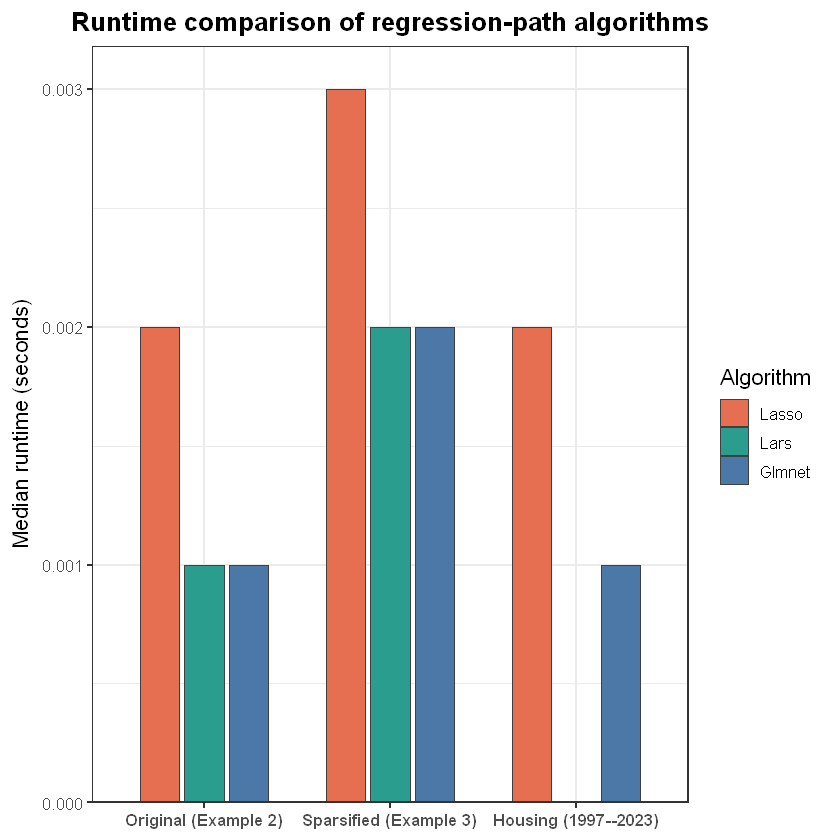

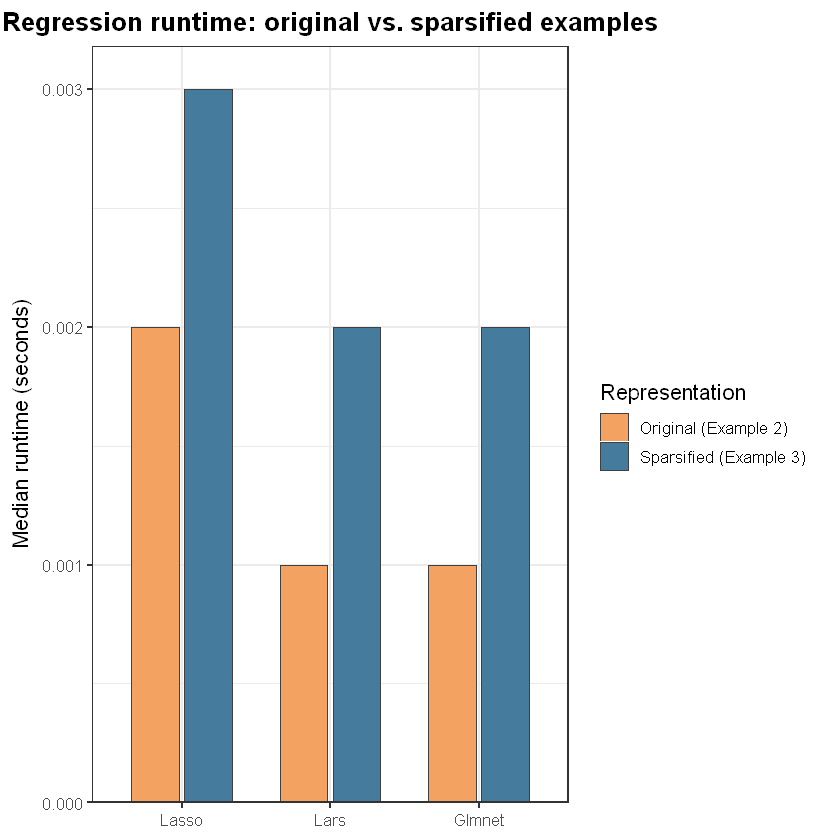

In [6]:
# Plot regression runtimes -----------------------------------------------------

runtime_regression$algorithm <- factor(
  runtime_regression$algorithm,
  levels = c("lasso_original", "lars_fast", "glmnet_fast"),
  labels = c("Lasso", "Lars", "Glmnet")
)

runtime_regression$dataset <- factor(
  runtime_regression$dataset,
  levels = c("example_2", "example_3", "housing_1997_2023"),
  labels = c("Original (Example 2)", "Sparsified (Example 3)", "Housing (1997--2023)")
)

p_reg_alg <- ggplot(runtime_regression, aes(x = dataset, y = median_sec, fill = algorithm)) +
  geom_col(position = position_dodge(width = 0.72), width = 0.64, colour = "grey25", linewidth = 0.2) +
  scale_y_continuous(labels = label_number(accuracy = 0.001), expand = expansion(mult = c(0, 0.06))) +
  scale_fill_manual(values = c("Lasso" = "#E76F51", "Lars" = "#2A9D8F", "Glmnet" = "#4C78A8")) +
  labs(
    x = NULL,
    y = "Median runtime (seconds)",
    fill = "Algorithm",
    title = "Runtime comparison of regression-path algorithms"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "right",
    axis.text.x = element_text(face = "bold")
  )

p_reg_alg
save_plot_files(p_reg_alg, "runtime_regression_algorithms", width = 9.2, height = 5.6)

# Direct original vs. sparsified comparison for regression examples ------------

runtime_regression_pair <- subset(runtime_regression, dataset %in% c("Original (Example 2)", "Sparsified (Example 3)"))

p_reg_sparse <- ggplot(runtime_regression_pair, aes(x = algorithm, y = median_sec, fill = dataset)) +
  geom_col(position = position_dodge(width = 0.72), width = 0.64, colour = "grey25", linewidth = 0.2) +
  scale_y_continuous(labels = label_number(accuracy = 0.001), expand = expansion(mult = c(0, 0.06))) +
  scale_fill_manual(values = c("Original (Example 2)" = "#F4A261", "Sparsified (Example 3)" = "#457B9D")) +
  labs(
    x = NULL,
    y = "Median runtime (seconds)",
    fill = "Representation",
    title = "Regression runtime: original vs. sparsified examples"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "right"
  )

p_reg_sparse
save_plot_files(p_reg_sparse, "runtime_regression_original_vs_sparsified", width = 8.2, height = 5.3)



## 3. Load and preprocess the UCI clustering datasets

This section reuses the same UCI datasets and the same sparse orthogonalization strategy as the earlier notebook. All tables and figures are saved to `outputs_runtime/`.


In [7]:
# UCI dataset specifications ---------------------------------------------------

uci_specs <- list(
  breast_tissue = list(
    aliases = c("breast_tissue"),
    label_candidates = c("class", "label"),
    drop_candidates = c("case", "case_number")
  ),
  hcv = list(
    aliases = c("hcv"),
    label_candidates = c("class", "category", "label"),
    drop_candidates = c("unnamed_0")
  ),
  wholesale_customers = list(
    aliases = c("wholesale_customers"),
    label_candidates = c("class", "label", "channel"),
    drop_candidates = c("region", "customer_id")
  ),
  vehicle_silhouettes = list(
    aliases = c("vehicle_silhouettes", "vehicle_silhouette"),
    label_candidates = c("class", "label"),
    drop_candidates = character(0)
  ),
  statlog_image_segmentation = list(
    aliases = c("statlog_image_segmentation", "image_segmentation", "statlog_segment"),
    label_candidates = c("class", "label"),
    drop_candidates = c("region_pixel_count")
  ),
  vertebral_column_3classes = list(
    aliases = c("vertebral_column_3classes", "vertebral_column_3_classes", "vertebral_3classes"),
    label_candidates = c("class", "label"),
    drop_candidates = character(0)
  ),
  vertebral_column_2classes = list(
    aliases = c("vertebral_column_2classes", "vertebral_column_2_classes", "vertebral_2classes"),
    label_candidates = c("class", "label"),
    drop_candidates = character(0)
  ),
  user_knowledge_modeling = list(
    aliases = c("user_knowledge_modeling", "user_knowledge_modelling"),
    label_candidates = c("class", "label"),
    drop_candidates = character(0)
  ),
  banknote_authentication = list(
    aliases = c("banknote_authentication", "banknote_authentication_dataset", "banknote_auth"),
    label_candidates = c("class", "label"),
    drop_candidates = character(0)
  ),
  wine = list(
    aliases = c("wine"),
    label_candidates = c("class", "label"),
    drop_candidates = character(0)
  )
)

uci_prepared <- list()
uci_overview <- data.frame()

for (nm in names(uci_specs)) {
  spec <- uci_specs[[nm]]
  path <- find_data_file_multi(spec$aliases)
  if (is.na(path)) {
    warning(sprintf("Dataset file not found for %s", nm))
    next
  }

  raw_df <- read_tabular_file(path)
  prep <- prepare_dataset_for_clustering(
    raw_df,
    dataset_key = nm,
    label_candidates = spec$label_candidates,
    drop_candidates = spec$drop_candidates,
    prefer_last_column = TRUE
  )

  uci_prepared[[nm]] <- prep
  uci_overview <- rbind(
    uci_overview,
    data.frame(
      dataset = nm,
      n = prep$n,
      p_original = prep$p,
      p_sparsified = prep$p_sparse,
      true_k = prep$true_k
    )
  )
}

uci_overview
write.csv(uci_overview, file.path(output_dir, "runtime_uci_dataset_overview.csv"), row.names = FALSE)


dataset,n,p_original,p_sparsified,true_k
<chr>,<int>,<int>,<int>,<int>
breast_tissue,106,9,36,6
hcv,615,13,49,5
wholesale_customers,440,7,25,3
vehicle_silhouettes,846,18,72,4
statlog_image_segmentation,2310,18,66,7
vertebral_column_3classes,310,6,24,3
vertebral_column_2classes,310,6,24,2
user_knowledge_modeling,403,5,20,5
banknote_authentication,1372,4,16,2


## 4. Benchmark $k$-means runtime on the UCI datasets

For each UCI dataset, the notebook compares runtime at the label-based number of clusters:
- original representation
- sparsified representation


In [8]:
# Benchmark k-means runtime on UCI datasets -----------------------------------

runtime_kmeans_uci <- data.frame()

for (nm in names(uci_prepared)) {
  prep <- uci_prepared[[nm]]
  k_true <- prep$true_k

  benchmark_specs <- list(
    original = prep$X_original,
    sparsified = prep$X_sparsified
  )

  for (rep_name in names(benchmark_specs)) {
    X <- benchmark_specs[[rep_name]]

    # Fewer repetitions for larger datasets to keep total runtime manageable.
    reps <- if (nrow(X) >= 1500) 25 else if (nrow(X) >= 800) 35 else 50
    inner_rep <- if (nrow(X) >= 1500) 1 else 3

    cat(sprintf("Benchmarking k-means runtime | dataset=%s | representation=%s | k=%d\n", nm, rep_name, k_true))

    res <- benchmark_fun(
      function() kmeans(X, centers = k_true, nstart = 30, iter.max = 100),
      reps = reps,
      warmup = 3,
      inner_rep = inner_rep
    )

    res$dataset <- nm
    res$representation <- rep_name
    res$k <- k_true
    res$n <- nrow(X)
    res$p <- ncol(X)

    runtime_kmeans_uci <- rbind(runtime_kmeans_uci, res)
  }
}

runtime_kmeans_uci <- runtime_kmeans_uci[, c("dataset", "representation", "k", "n", "p", "mean_sec", "median_sec", "sd_sec", "min_sec", "max_sec", "reps", "inner_rep")]
runtime_kmeans_uci
write.csv(runtime_kmeans_uci, file.path(output_dir, "runtime_kmeans_uci_original_vs_sparsified.csv"), row.names = FALSE)


Benchmarking k-means runtime | dataset=breast_tissue | representation=original | k=6
Benchmarking k-means runtime | dataset=breast_tissue | representation=sparsified | k=6
Benchmarking k-means runtime | dataset=hcv | representation=original | k=5
Benchmarking k-means runtime | dataset=hcv | representation=sparsified | k=5
Benchmarking k-means runtime | dataset=wholesale_customers | representation=original | k=3
Benchmarking k-means runtime | dataset=wholesale_customers | representation=sparsified | k=3
Benchmarking k-means runtime | dataset=vehicle_silhouettes | representation=original | k=4
Benchmarking k-means runtime | dataset=vehicle_silhouettes | representation=sparsified | k=4
Benchmarking k-means runtime | dataset=statlog_image_segmentation | representation=original | k=7
Benchmarking k-means runtime | dataset=statlog_image_segmentation | representation=sparsified | k=7
Benchmarking k-means runtime | dataset=vertebral_column_3classes | representation=original | k=3
Benchmarking 

dataset,representation,k,n,p,mean_sec,median_sec,sd_sec,min_sec,max_sec,reps,inner_rep
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
breast_tissue,original,6,106,9,0.004133333,0.003333333,0.002569664,0.000000000,0.006666667,50,3
breast_tissue,sparsified,6,106,36,0.018933333,0.020000000,0.005731719,0.003333333,0.026666667,50,3
hcv,original,5,615,13,0.041533333,0.030000000,0.016811749,0.020000000,0.083333333,50,3
hcv,sparsified,5,615,49,0.158066667,0.165000000,0.058025290,0.090000000,0.260000000,50,3
wholesale_customers,original,3,440,7,0.011666667,0.010000000,0.005139770,0.003333333,0.023333333,50,3
wholesale_customers,sparsified,3,440,25,0.027733333,0.026666667,0.009815532,0.020000000,0.056666667,50,3
vehicle_silhouettes,original,4,846,18,0.045809524,0.043333333,0.014080600,0.036666667,0.093333333,35,3
vehicle_silhouettes,sparsified,4,846,72,0.139428571,0.140000000,0.011418530,0.120000000,0.156666667,35,3
statlog_image_segmentation,original,7,2310,18,0.151600000,0.160000000,0.016248077,0.120000000,0.190000000,25,1


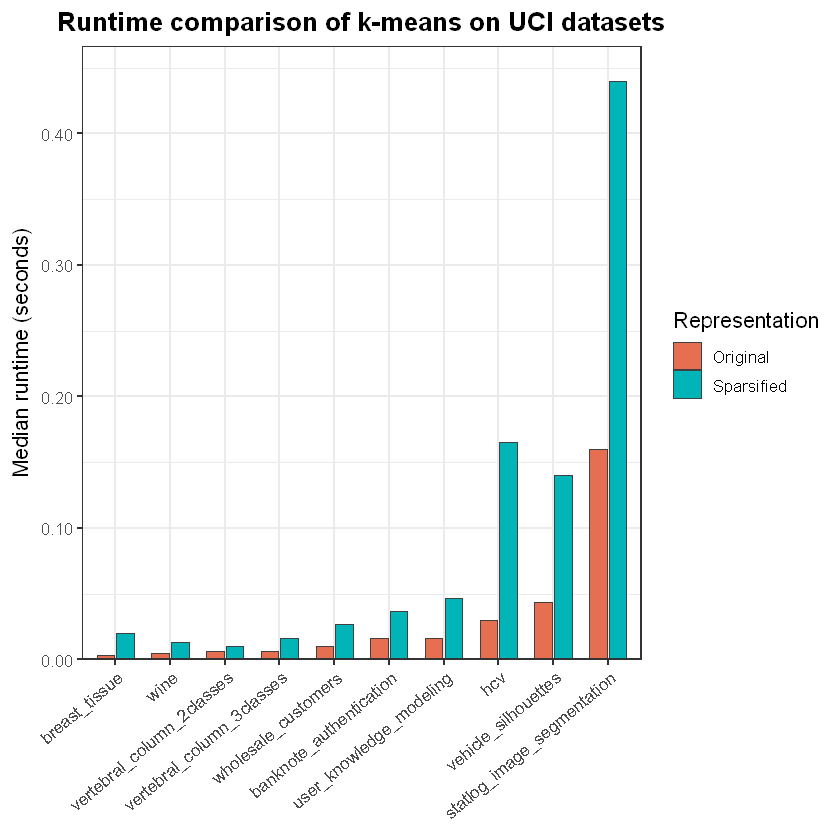

In [9]:
# Plot UCI k-means runtimes ----------------------------------------------------

runtime_kmeans_uci$representation <- factor(
  runtime_kmeans_uci$representation,
  levels = c("original", "sparsified"),
  labels = c("Original", "Sparsified")
)

# Create unique dataset order using one summary value per dataset
dataset_order <- tapply(runtime_kmeans_uci$median_sec, runtime_kmeans_uci$dataset, min)
dataset_levels <- names(sort(dataset_order))

runtime_kmeans_uci$dataset <- factor(
  runtime_kmeans_uci$dataset,
  levels = dataset_levels
)

p_uci <- ggplot(runtime_kmeans_uci, aes(x = dataset, y = median_sec, fill = representation)) +
  geom_col(
    position = position_dodge(width = 0.72),
    width = 0.64,
    colour = "grey25",
    linewidth = 0.2
  ) +
  scale_y_continuous(
    labels = label_number(accuracy = 0.01),
    expand = expansion(mult = c(0, 0.06))
  ) +
  scale_fill_manual(values = c("Original" = "#E76F51", "Sparsified" = "#00B4B8")) +
  labs(
    x = NULL,
    y = "Median runtime (seconds)",
    fill = "Representation",
    title = "Runtime comparison of k-means on UCI datasets"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "right",
    axis.text.x = element_text(angle = 40, hjust = 1, vjust = 1)
  )

print(p_uci)

save_plot_files(
  p_uci,
  "runtime_kmeans_uci_original_vs_sparsified",
  width = 10.5,
  height = 6.4
)

## 5. Benchmark exploratory $k$-means runtime on the Chinese housing dataset


In [10]:
# Chinese housing clustering runtime ------------------------------------------

housing_file <- find_data_file_multi(c("regression_data_1997_2023"))
if (is.na(housing_file)) stop("regression_data_1997_2023 file not found in data/ or current directory.")

housing_df <- read.csv(housing_file, stringsAsFactors = FALSE)
housing_X <- as.matrix(housing_df[, c("x1", "x2", "x3", "x4", "x5", "x6", "x7")])
housing_X_scaled <- scale(housing_X)
housing_X_sparse <- sparse_orthogonalize_matrix(housing_X_scaled, n_blocks = SPARSE_ORTHO_BINS)

runtime_housing_kmeans <- data.frame()
for (rep_name in c("original", "sparsified")) {
  X <- if (rep_name == "original") housing_X_scaled else housing_X_sparse

  res <- benchmark_fun(
    function() kmeans(X, centers = 4, nstart = 30, iter.max = 100),
    reps = 80,
    warmup = 3,
    inner_rep = 5
  )

  res$dataset <- "housing_years"
  res$representation <- rep_name
  res$k <- 4
  res$n <- nrow(X)
  res$p <- ncol(X)

  runtime_housing_kmeans <- rbind(runtime_housing_kmeans, res)
}

runtime_housing_kmeans <- runtime_housing_kmeans[, c("dataset", "representation", "k", "n", "p", "mean_sec", "median_sec", "sd_sec", "min_sec", "max_sec", "reps", "inner_rep")]
runtime_housing_kmeans
write.csv(runtime_housing_kmeans, file.path(output_dir, "runtime_kmeans_housing_original_vs_sparsified.csv"), row.names = FALSE)


dataset,representation,k,n,p,mean_sec,median_sec,sd_sec,min_sec,max_sec,reps,inner_rep
<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
housing_years,original,4,27,7,0.0018,0.002,0.001760322,0,0.004,80,5
housing_years,sparsified,4,27,28,0.0021,0.002,0.001680868,0,0.004,80,5


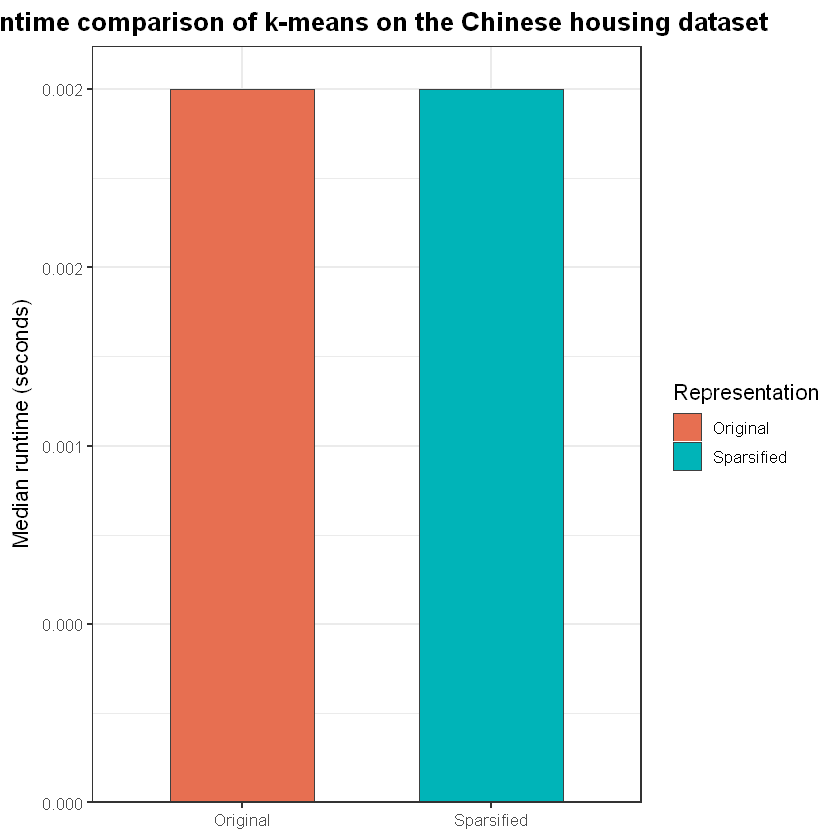

In [11]:
# Plot housing k-means runtimes ------------------------------------------------

runtime_housing_kmeans$representation <- factor(
  runtime_housing_kmeans$representation,
  levels = c("original", "sparsified"),
  labels = c("Original", "Sparsified")
)

p_house <- ggplot(runtime_housing_kmeans, aes(x = representation, y = median_sec, fill = representation)) +
  geom_col(width = 0.58, colour = "grey25", linewidth = 0.2) +
  scale_y_continuous(labels = label_number(accuracy = 0.001), expand = expansion(mult = c(0, 0.06))) +
  scale_fill_manual(values = c("Original" = "#E76F51", "Sparsified" = "#00B4B8")) +
  labs(
    x = NULL,
    y = "Median runtime (seconds)",
    fill = "Representation",
    title = "Runtime comparison of k-means on the Chinese housing dataset"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "right"
  )

p_house
save_plot_files(p_house, "runtime_kmeans_housing_original_vs_sparsified", width = 6.8, height = 5.2)



## 6. Files created by this notebook

### In `outputs_runtime/`
- `runtime_regression_algorithms.csv`
- `runtime_regression_algorithms.pdf`
- `runtime_regression_algorithms.png`
- `runtime_regression_original_vs_sparsified.pdf`
- `runtime_regression_original_vs_sparsified.png`
- `runtime_uci_dataset_overview.csv`
- `runtime_kmeans_uci_original_vs_sparsified.csv`
- `runtime_kmeans_uci_original_vs_sparsified.pdf`
- `runtime_kmeans_uci_original_vs_sparsified.png`
- `runtime_kmeans_housing_original_vs_sparsified.csv`
- `runtime_kmeans_housing_original_vs_sparsified.pdf`
- `runtime_kmeans_housing_original_vs_sparsified.png`

